In [ ]:
import pandas as pd
import re
!pip uninstall nltk -y
!pip install --upgrade nltk
import shutil
import nltk
# Remove NLTK data folder
shutil.rmtree('/root/nltk_data', ignore_errors=True)
nltk.download('punkt')
nltk.download('stopwords')
from nltk.tokenize import word_tokenize

Found existing installation: nltk 3.9.1
Uninstalling nltk-3.9.1:
  Successfully uninstalled nltk-3.9.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 13.4 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Lemmatization
import spacy
from nltk.stem import PorterStemmer
nlp = spacy.load("en_core_web_sm")


In [ ]:
df = pd.read_csv('/content/Airline_review_assignment_data.csv')
df.head()


,ID,Airline Name,Overall_Rating,Review_Title,Review Date,Verified,Review,Aircraft,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Ground Service,Inflight Entertainment,Wifi & Connectivity,Value For Money,Recommended
0,0,AB Aviation,9,"""pretty decent airline""",11th November 2019,True,Moroni to Moheli. Turned out to be a pretty ...,NaN,Solo Leisure,Economy Class,Moroni to Moheli,Nov-19,4.0,5.0,4.0,4.0,NaN,NaN,3.0,yes
1,1,AB Aviation,1,"""Not a good airline""",25th June 2019,True,Moroni to Anjouan. It is a very small airline...,E120,Solo Leisure,Economy Class,Moroni to Anjouan,Jun-19,2.0,2.0,1.0,1.0,NaN,NaN,2.0,no
2,2,AB Aviation,1,"""flight was fortunately short""",25th June 2019,True,Anjouan to Dzaoudzi. A very small airline an...,Embraer E120,Solo Leisure,Economy Class,Anjouan to Dzaoudzi,Jun-19,2.0,1.0,1.0,1.0,NaN,NaN,2.0,no
3,3,Adria Airways,1,"""I will never fly again with Adria""",28th September 2019,False,Please do a favor yourself and do not fly wi...,NaN,Solo Leisure,Economy Class,Frankfurt to Pristina,Sep-19,1.0,1.0,NaN,1.0,NaN,NaN,1.0,no
4,4,Adria Airways,1,"""it ruined our last days of holidays""",24th September 2019,True,Do not book a flight with this airline! My fr...,NaN,Couple Leisure,Economy Class,Sofia to Amsterdam via Ljubljana,Sep-19,1.0,1.0,1.0,1.0,1.0,1.0,1.0,no


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23171 entries, 0 to 23170
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   ID                      23171 non-null  int64         
 1   Airline Name            23171 non-null  object        
 2   Overall_Rating          23171 non-null  float64       
 3   Review_Title            23171 non-null  object        
 4   Review Date             23171 non-null  datetime64[ns]
 5   Verified                23171 non-null  bool          
 6   Review                  23171 non-null  object        
 7   Aircraft                23171 non-null  object        
 8   Type Of Traveller       23171 non-null  object        
 9   Seat Type               23171 non-null  object        
 10  Route                   23171 non-null  object        
 11  Date Flown              23171 non-null  datetime64[ns]
 12  Seat Comfort            23171 non-null  float6

In [ ]:
df.describe()

,ID,Overall_Rating,Review Date,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Ground Service,Inflight Entertainment,Wifi & Connectivity,Value For Money
count,23171.00000,23171.000000,23171,23171,23171.000000,23171.000000,23171.000000,23171.000000,23171.000000,23171.000000,23171.000000
mean,11585.00000,3.067714,2019-04-11 06:37:33.126753280,2019-04-11 06:37:33.126753280,2.686807,2.895214,2.346424,2.073713,1.018385,0.454879,2.430409
min,0.00000,1.000000,2002-01-06 00:00:00,2002-01-06 00:00:00,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,5792.50000,1.000000,2017-01-14 12:00:00,2017-01-14 12:00:00,1.000000,1.000000,2.000000,1.000000,0.000000,0.000000,1.000000
50%,11585.00000,1.000000,2020-01-13 00:00:00,2020-01-13 00:00:00,3.000000,3.000000,2.000000,1.000000,0.000000,0.000000,2.000000
75%,17377.50000,5.000000,2022-12-08 00:00:00,2022-12-08 00:00:00,4.000000,4.000000,3.000000,3.000000,1.000000,1.000000,4.000000
max,23170.00000,9.000000,2023-07-27 00:00:00,2023-07-27 00:00:00,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
std,6689.03588,2.855404,NaN,NaN,1.335065,1.450486,1.236760,1.523264,1.489282,1.023369,1.559917


In [ ]:
df.isnull().sum()

,0
ID,0
Airline Name,0
Overall_Rating,0
Review_Title,0
Review Date,0
Verified,0
Review,0
Aircraft,0
Type Of Traveller,0
Seat Type,0


In [ ]:
# Impute missing categorical data with the mode (      frequent category)
df['Aircraft'].fillna(df['Aircraft'].mode()[0], inplace=True)
df['Type Of Traveller'].fillna(df['Type Of Traveller'].mode()[0], inplace=True)
df['Seat Type'].fillna(df['Seat Type'].mode()[0], inplace=True)
df['Route'].fillna(df['Route'].mode()[0], inplace=True)


# Impute missing numerical data with the median
df['Seat Comfort'].fillna(df['Seat Comfort'].median(), inplace=True)
df['Cabin Staff Service'].fillna(df['Cabin Staff Service'].median(), inplace=True)
df['Food & Beverages'].fillna(df['Food & Beverages'].median(), inplace=True)
df['Ground Service'].fillna(df['Ground Service'].median(), inplace=True)
df['Value For Money'].fillna(df['Value For Money'].median(), inplace=True)


# Impute InflightEntairtaiment and Wifi & Connectivity with 0
df['Inflight Entertainment'].fillna(0, inplace=True)
df['Wifi & Connectivity'].fillna(0, inplace=True)


<ipython-input-19-cdb9eb03bbae>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Aircraft'].fillna(df['Aircraft'].mode()[0], inplace=True)
<ipython-input-19-cdb9eb03bbae>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

In [ ]:
# Function to replace ordinal suffixes
def remove_ordinal_suffixes(date_str):
    # Replace ordinal suffixes with an empty string
    return re.sub(r"(?<=\d)(st|nd|rd|th)", "", date_str)
# Apply the function to the 'Review Date' column
df['Review Date'] = df['Review Date'].apply(remove_ordinal_suffixes)
# Convert 'Review Date' to datetime
df['Review Date'] = pd.to_datetime(df['Review Date'], format='%d %B %Y')
df['Date Flown'] = pd.to_datetime(df['Date Flown'], format='%B %Y', errors='coerce')
# Impute missing 'Date Flown' values with 'Review Date' values
df['Date Flown'].fillna(df['Review Date'], inplace=True)
df[['Review Date', 'Date Flown']].head()

<ipython-input-20-1b5d92b7eb1a>:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Date Flown'].fillna(df['Review Date'], inplace=True)


,Review Date,Date Flown
0,2019-11-11,2019-11-11
1,2019-06-25,2019-06-25
2,2019-06-25,2019-06-25
3,2019-09-28,2019-09-28
4,2019-09-24,2019-09-24


In [ ]:
import numpy as np
# Convert 'Overall_Rating' to numeric, setting invalid values like 'n' as NaN
df['Overall_Rating'] = pd.to_numeric(df['Overall_Rating'], errors='coerce')

# Compute the median rating where Recommended is 'Yes'
median_rating_yes = df.loc[df['Recommended'] == 'yes', 'Overall_Rating'].median()

# Define imputation logic
def impute_rating(row):
    if np.isnan(row['Overall_Rating']):
        if row['Recommended'] == 'no':
            return 1
        elif row['Recommended'] == 'yes':
            return median_rating_yes
    return row['Overall_Rating']

# Apply the function row-wise
df['Overall_Rating'] = df.apply(impute_rating, axis=1)

# Verify the changes: Check if any NaNs remain in Overall_Rating
remaining_nans = df['Overall_Rating'].isna().sum()
remaining_nans

np.int64(0)

In [ ]:
###########################################################################################################################################################
##########################################                       TEXT DATA CLEANING           |        ####################################################
###########################################################################################################################################################

In [ ]:
!pip uninstall nltk -y
!pip install --upgrade nltk

import shutil
import nltk

# Remove NLTK data folder
shutil.rmtree('/root/nltk_data', ignore_errors=True)

nltk.download('punkt')  # Download the necessary data (if not already downloaded)

from nltk.tokenize import word_tokenize

Found existing installation: nltk 3.9.1
Uninstalling nltk-3.9.1:
  Successfully uninstalled nltk-3.9.1
  Using cached nltk-3.9.1-py3-none-any.whl.metadata (2.9 kB)
Using cached nltk-3.9.1-py3-none-any.whl (1.5 MB)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:
import string # Import the 'string' module

def clean_text(text):

    text = re.sub(r'<.*?>', '', text) # Remove HTML tags
    text = ''.join([char for char in text if char not in string.punctuation]) # Remove punctuation and special characters
    text = text.lower() # Convert text to lowercase
    return text

# Apply the cleaning function to the 'Review' column
df['Review'] = df['Review'].apply(clean_text)

# Display the first few rows to confirm the changes
print(df['Review'].head())



0      moroni to moheli turned out to be a pretty d...
1     moroni to anjouan it is a very small airline ...
2      anjouan to dzaoudzi a very small airline and...
3      please do a favor yourself and do not fly wi...
4     do not book a flight with this airline my fri...
Name: Review, dtype: object


In [ ]:
from nltk.tokenize import TreebankWordTokenizer

# Assuming df is your DataFrame and it's already loaded with the 'Review' column lowered

# Define the tokenization function
def tokenize_text(text):
    tokenizer = TreebankWordTokenizer()  # Initialize the tokenizer
    if pd.isna(text):  # Check if the text is NaN
        return []  # Return an empty list if text is NaN
    tokens = tokenizer.tokenize(text)  # Use the tokenize() method
    return tokens

# Apply the tokenization to the 'Review' column
df['Review'] = df['Review'].apply(tokenize_text)

# Display the first few rows to confirm the tokenization
df['Review'].head()


,Review
0,"[moroni, to, moheli, turned, out, to, be, a, p..."
1,"[moroni, to, anjouan, it, is, a, very, small, ..."
2,"[anjouan, to, dzaoudzi, a, very, small, airlin..."
3,"[please, do, a, favor, yourself, and, do, not,..."
4,"[do, not, book, a, flight, with, this, airline..."


In [ ]:
############################
###  Removing StopWords  ###
############################
import nltk
from nltk.corpus import stopwords # Import the stopwords module
nltk.download('stopwords', download_dir='/root/nltk_data')

def remove_stopwords(tokens):
    stop_words = set(stopwords.words('english')) # Get the list of English stopwords
    filtered_tokens = [word for word in tokens if word.lower() not in stop_words] # Remove stopwords from the list of tokens
    filtered_text = ' '.join(filtered_tokens) # Reconstruct the text without stopwords

    return filtered_text


# Applying the function to the 'Cleaned Review after Tokenization' column
df['Review'] = df['Review'].apply(remove_stopwords)

# Display the first few rows to confirm the changes
df['Review'].head()



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,Review
0,moroni moheli turned pretty decent airline onl...
1,moroni anjouan small airline ticket advised tu...
2,anjouan dzaoudzi small airline airline based c...
3,please favor fly adria route munich pristina j...
4,book flight airline friend returned sofia amst...


In [ ]:
######################################################
### Stemming & Lemmatization   #######################
#######################################################

import spacy

# Load the English tokenizer, tagger, parser, NER, and word vectors
nlp = spacy.load("en_core_web_sm")

def lemmatize_text(text):
    # Process the text through spaCy's pipeline
    doc = nlp(text)
    # Extract lemmas for each token and return them as a space-separated string
    lemmatized_text = " ".join([token.lemma_ for token in doc])
    return lemmatized_text

# Apply the lemmatization function to the 'Review' column
df['Review'] = df['Review'].apply(lemmatize_text)

# Display the first few rows to check the output
df['Review'].head()


,Review
0,moroni moheli turn pretty decent airline onlin...
1,moroni anjouan small airline ticket advise tur...
2,anjouan dzaoudzi small airline airline base co...
3,please favor fly adria route munich pristina j...
4,book flight airline friend return sofia amster...


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialize the CountVectorizer for bi-grams (n=2)
vectorizer_ngrams = CountVectorizer(ngram_range=(2, 2))  # You can adjust ngram_range to (1, 2) for uni- and bi-grams, etc.

# Fit and transform the 'Review' column to a BoW model using bi-grams
X_bow_ngrams = vectorizer_ngrams.fit_transform(df['Review'])

# Get the sum of each bi-gram across all documents (summing down the columns)
sum_words = X_bow_ngrams.sum(axis=0)

# Map sum counts with their respective bi-grams into a list of tuples and sort them by frequency
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer_ngrams.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

# Display the top 10 most common bi-grams
top_n_bigrams = words_freq[:10]
top_n_bigrams


[('customer service', np.int64(4000)),
 ('cabin crew', np.int64(2478)),
 ('business class', np.int64(2315)),
 ('flight delayed', np.int64(1636)),
 ('return flight', np.int64(1437)),
 ('flight attendants', np.int64(1330)),
 ('even though', np.int64(1037)),
 ('connecting flight', np.int64(1029)),
 ('flight cancelled', np.int64(989)),
 ('never fly', np.int64(966))]

In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

# Assuming df is your DataFrame and 'Processed_Review' is the column with the processed text
# Initialize CountVectorizer for bi-grams
vectorizer = CountVectorizer(ngram_range=(2, 2))

# Fit and transform the 'Processed_Review' column to a BoW model using bi-grams
X_bow = vectorizer.fit_transform(df['Processed_Review'])

# Get the sum of each bi-gram across all documents (summing down the columns)
sum_words = X_bow.sum(axis=0)

# Map sum counts with their respective bi-grams into a list of tuples and sort them by frequency
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

# Extracting top 10 most frequent bi-grams
top_n_bigrams = words_freq[:10]

# Prepare data for plotting
bi_grams = [i[0] for i in top_n_bigrams]
counts = [i[1] for i in top_n_bigrams]

# Plotting the top N bi-grams
plt.figure(figsize=(10, 6))
plt.bar(bi_grams, counts, color='blue')
plt.title('Top 10 Bi-grams in Reviews')
plt.xlabel('Bi-grams')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()


KeyError: 'Processed_Review'

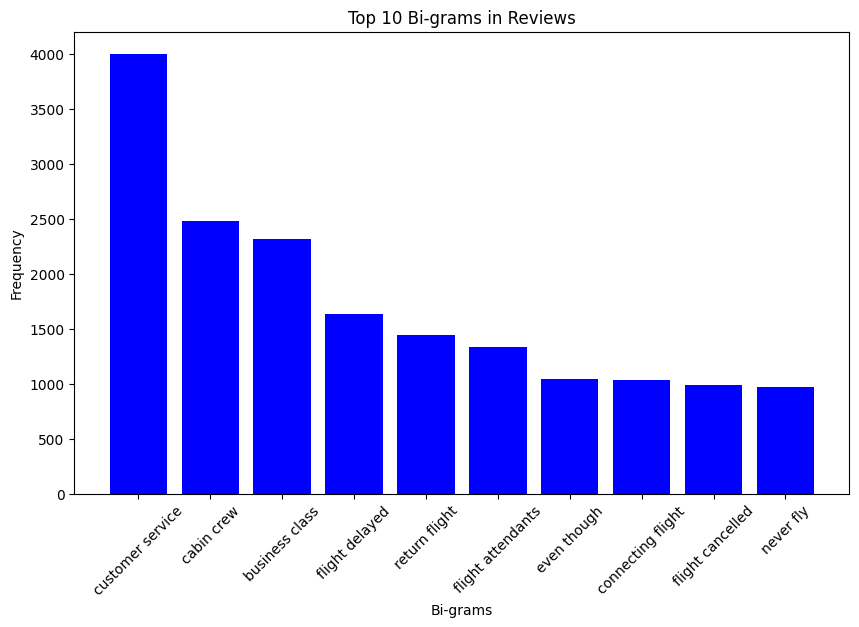

In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

# Assuming df is your DataFrame and 'Review' is the column with the processed text
# Initialize CountVectorizer for bi-grams
vectorizer = CountVectorizer(ngram_range=(2, 2))

# Fit and transform the 'Review' column to a BoW model using bi-grams
# Changed 'Processed_Review' to 'Review'
X_bow = vectorizer.fit_transform(df['Review'])

# Get the sum of each bi-gram across all documents (summing down the columns)
sum_words = X_bow.sum(axis=0)

# Map sum counts with their respective bi-grams into a list of tuples and sort them by frequency
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

# Extracting top 10 most frequent bi-grams
top_n_bigrams = words_freq[:10]

# Prepare data for plotting
bi_grams = [i[0] for i in top_n_bigrams]
counts = [i[1] for i in top_n_bigrams]

# Plotting the top N bi-grams
plt.figure(figsize=(10, 6))
plt.bar(bi_grams, counts, color='blue')
plt.title('Top 10 Bi-grams in Reviews')
plt.xlabel('Bi-grams')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()